# Nama   : Sayyidah Afifatuz Zahro
# NPM    : 25083010004
# Kelas  : Analisis Numerik (A)

# Tugas Analisis Numerik: Volume Kedua Lambung Katamaran


## 1. Penjelasan soal
Diberikan gambar katamaran (tampak atas dan tampak samping) dengan grid berdash. Diminta menghitung **volume kedua lambung**, dengan ketentuan:
- Satu dash + kosong = 5 + 5 = **10 cm** (ini dasar skala gambar).
- Lantai kapal datar (tanpa keel), jadi **tampak depan berupa persegi panjang**.
- **Volume reserve buoyancy tidak dihitung**, jadi integrasi hanya di antara dua sekat reserve buoyancy.

## 2. Model matematika
Volume = integral luas penampang sepanjang lambung:

$$V=\int_{x_a}^{x_b} A(x)\,dx, \qquad A(x)=B(x)\cdot T(x)$$

- $B(x)$: lebar lambung (dibaca dari **tampak atas**)
- $T(x)$: tinggi lambung dari garis dek sampai dasar (dibaca dari **tampak samping**)
- $x_a, x_b$: posisi dua sekat reserve buoyancy

$A(x)$ tidak punya rumus, hanya bisa diukur di titik-titik tertentu. Karena itu integralnya dihitung secara **numerik**. Volume total = 2 × volume satu lambung, sebab kedua lambung identik.

## 3. Metode numerik
Bagi $[x_a,x_b]$ menjadi $n$ interval sama lebar $h=(x_b-x_a)/n$, sehingga ada $n+1$ titik $x_0,\dots,x_n$.

- **Trapesium:** $V\approx h\left[\dfrac{A_0+A_n}{2}+\sum_{i=1}^{n-1}A_i\right]$ (galat $O(h^2)$)
- **Simpson 1/3** ($n$ harus genap): $V\approx \dfrac{h}{3}\left[A_0+A_n+4\sum_{i\ ganjil}A_i+2\sum_{i\ genap}A_i\right]$ (galat $O(h^4)$)

Pola bobot Simpson: **1, 4, 2, 4, 2, ..., 4, 1**. Dipakai $n=16$ (17 titik).



## 4. Persiapan dan unggah file
Jalankan sel di bawah, lalu **unggah `perahu.pdf`** saat diminta (atau unggah lebih dulu lewat ikon folder di kiri). Sel ini memuat library (`numpy`, `pandas`, `matplotlib`, `scipy`, `pdf2image`).

In [ ]:
import os, sys, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.ndimage import median_filter, binary_dilation
from IPython.display import display

try:
    from pdf2image import convert_from_path
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pdf2image"])
    from pdf2image import convert_from_path

if not os.path.exists("perahu.pdf"):
    from google.colab import files
    print("Silakan unggah file perahu.pdf")
    files.upload()

print("perahu.pdf tersedia:", os.path.exists("perahu.pdf"))

Silakan unggah file perahu.pdf


Saving perahu.pdf to perahu.pdf
perahu.pdf tersedia: True


## 5. Mengubah PDF menjadi gambar
PDF dirender menjadi gambar **300 dpi** agar tiap garis bisa diukur sampai ketelitian piksel. Halaman 1 berisi tampak atas dan tampak samping.

Ukuran gambar (tinggi x lebar, piksel): (1861, 3308)


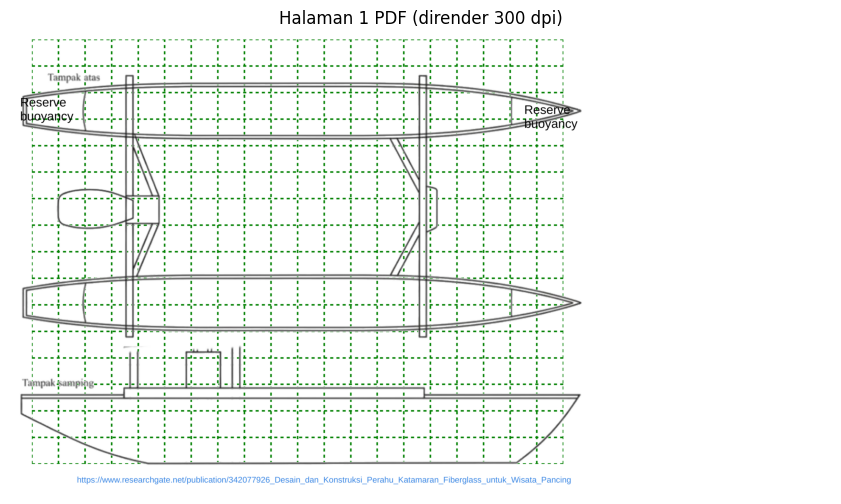

In [ ]:
import subprocess
import sys

# Memastikan poppler-utils terinstal di sistem Colab
try:
    # Jalankan perintah sistem untuk menginstal poppler-utils secara diam-diam
    subprocess.run(["sudo", "apt-get", "update", "-y"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.run(["sudo", "apt-get", "install", "-y", "poppler-utils"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
except Exception as e:
    print("Gagal menginstal poppler-utils secara otomatis:", e)

pil = convert_from_path("perahu.pdf", dpi=300, first_page=1, last_page=1)[0].convert("RGB")
img = np.array(pil).astype(int)
R, G, Bc = img[..., 0], img[..., 1], img[..., 2]
print("Ukuran gambar (tinggi x lebar, piksel):", img.shape[:2])

plt.figure(figsize=(12, 6))
plt.imshow(pil)
plt.axis("off")
plt.title("Halaman 1 PDF (dirender 300 dpi)")
plt.show()

**Interpretasi:** gambar berukuran 1861 × 3308 piksel. Dari sini semua ukuran diambil dalam satuan **piksel**, lalu diubah ke cm memakai skala pada langkah berikutnya.

## 6. Kalibrasi skala (langkah paling penting)
Kode memisahkan warna: **hijau = grid**, **abu-abu gelap = garis lambung**. Lalu kode mengukur panjang satu periode dash (dash + kosong) pada garis grid. Karena periode itu = 10 cm, skala gambar bisa dihitung.

In [ ]:
# Piksel hijau = grid, piksel abu-abu gelap = garis lambung
green = (G > R + 40) & (G > Bc + 40)
dark  = (R < 150) & (G < 150) & (Bc < 150) & (abs(R - G) < 35) & (abs(G - Bc) < 35)

def kelompok(idx, gap=3):
    """Gabungkan indeks yang berdekatan menjadi satu posisi (rata-rata)."""
    out, cur = [], [idx[0]]
    for v in idx[1:]:
        if v - cur[-1] <= gap:
            cur.append(v)
        else:
            out.append(np.mean(cur)); cur = [v]
    out.append(np.mean(cur))
    return np.array(out)

# 1) jarak antar garis grid vertikal
grid_x = kelompok(np.where(green.sum(axis=0) > 600)[0])
jarak_grid_px = np.median(np.diff(grid_x))

# 2) periode dash (awal dash ke awal dash berikutnya) pada salah satu garis grid
c = int(grid_x[3])
kolom = green[:, c - 3:c + 4].any(axis=1)
awal = np.where(kolom[1:] & ~kolom[:-1])[0]
selisih = np.diff(awal)
selisih = selisih[(selisih > 20) & (selisih < 30)]
periode_dash_px = np.median(selisih)

# 3) skala: 1 dash + 1 kosong = 5 + 5 = 10 cm
CM = 10.0 / periode_dash_px

print(f"Jumlah garis grid vertikal terdeteksi : {len(grid_x)}")
print(f"Jarak antar garis grid                : {jarak_grid_px:.1f} piksel")
print(f"Periode (dash + kosong)               : {periode_dash_px:.1f} piksel = 10 cm")
print(f"SKALA                                 : 1 piksel = {CM:.3f} cm")
print(f"Jarak antar garis grid                : {jarak_grid_px*CM:.1f} cm  (= {jarak_grid_px/periode_dash_px:.2f} dash)")

Jumlah garis grid vertikal terdeteksi : 21
Jarak antar garis grid                : 107.0 piksel
Periode (dash + kosong)               : 25.0 piksel = 10 cm
SKALA                                 : 1 piksel = 0.400 cm
Jarak antar garis grid                : 42.8 cm  (= 4.28 dash)


**Interpretasi:**
- Satu periode dash = **25 piksel = 10 cm**, jadi **1 piksel = 0,4 cm**.
- Jarak antar garis grid = 107 piksel = **42,8 cm**, atau sekitar **4,28 dash**. Jadi satu kotak grid **bukan** 5 dash (50 cm) dan bukan pula bilangan bulat dash.
- Skala ini sangat berpengaruh karena volume sebanding dengan skala **pangkat 3** (lihat bagian 14).

### 7. Mengukur lambung, sekat, dan tinggi dari gambar
- **Lebar B(x):** untuk tiap kolom piksel, dicari tepi bawah lambung di tampak atas. Lambung simetris terhadap sumbunya, sehingga lebar = 2 × jarak tepi bawah ke sumbu. Tepi bawah dipakai karena tepi atas lambung bawah terganggu penyangga. Kolom yang tertutup balok melintang dideteksi otomatis lalu diinterpolasi.
- **Sekat reserve buoyancy:** dicari garis vertikal di dalam lambung. Yang paling kiri dan paling kanan adalah $x_a$ dan $x_b$.
- **Tinggi T(x):** di tampak samping, T = posisi dasar lambung dikurangi posisi garis dek.

In [ ]:
# ---------- TAMPAK ATAS (lambung bawah, tidak tertutup penyangga di sisi luarnya) ----------
Y_ATAS = (960, 1220)
sub = dark[Y_ATAS[0]:Y_ATAS[1]]
kol = np.where(sub.any(axis=0))[0]
x_min, x_max = kol.min(), kol.max()
X = np.arange(x_min, x_max + 1)

y_top = np.array([np.where(sub[:, c])[0].min() for c in X]) + Y_ATAS[0]
y_bot = np.array([np.where(sub[:, c])[0].max() for c in X]) + Y_ATAS[0]

tengah = len(X) // 2
pusat = (y_top[tengah] + y_bot[tengah]) / 2          # sumbu simetri lambung (piksel)
setengah = (y_bot - pusat).astype(float)             # setengah lebar = tepi bawah - sumbu

# kolom yang terganggu balok melintang dideteksi otomatis lalu diinterpolasi
halus = median_filter(setengah, size=201, mode="nearest")
buruk = binary_dilation(np.abs(setengah - halus) > 6, iterations=4)
setengah_ok = np.interp(X, X[~buruk], setengah[~buruk])
W_px = 2 * setengah_ok                               # lebar B(x) dalam piksel

# lambung atas: sumbu simetrinya diukur dengan cara sama
sub_up = dark[150:480]
cu = x_min + len(X) // 2
ys_up = np.where(sub_up[:, cu])[0] + 150
pusat_atas = (ys_up.min() + ys_up.max()) / 2

# ---------- SEKAT RESERVE BUOYANCY = garis vertikal di dalam lambung ----------
band = dark[int(pusat) - 45:int(pusat) + 45]
cnt = band.sum(axis=0)
kandidat = np.where(cnt >= 40)[0]
kandidat = kandidat[(kandidat > x_min + 100) & (kandidat < x_max - 100)]
klp = kelompok(kandidat)
x_a, x_b = klp[0], klp[-1]

# ---------- TAMPAK SAMPING ----------
Y_SAMPING = (1420, 1800)
sv = dark[Y_SAMPING[0]:Y_SAMPING[1]]
ks = np.where(sv.any(axis=0))[0]
s_min, s_max = ks.min(), ks.max()
S = np.arange(s_min, s_max + 1)
dek = int(np.median([np.where(sv[:, c])[0].min() for c in range(s_min + 150, s_min + 450)])) + Y_SAMPING[0]
dasar = np.array([np.where(sv[:, c])[0].max() for c in S]) + Y_SAMPING[0]
T_px = (dasar - dek).astype(float)                   # tinggi T(x) dalam piksel

print(f"Panjang lambung total     : {(x_max-x_min)*CM:.0f} cm")
print(f"Sekat kiri / kanan (px)   : {x_a:.1f} / {x_b:.1f}")
print(f"Panjang yang diintegrasi  : {(x_b-x_a)*CM:.1f} cm")
print(f"Sumbu lambung bawah/atas  : y = {pusat:.1f} / {pusat_atas:.1f} px")
print(f"Garis dek (tampak samping): y = {dek} px")
print(f"Lebar maksimum            : {W_px.max()*CM:.1f} cm")
print(f"Tinggi maksimum           : {T_px.max()*CM:.1f} cm")
print(f"Kolom terganggu balok     : {buruk.sum()} kolom (diinterpolasi)")

Panjang lambung total     : 899 cm
Sekat kiri / kanan (px)   : 294.5 / 2018.0
Panjang yang diintegrasi  : 689.4 cm
Sumbu lambung bawah/atas  : y = 1090.5 / 318.0 px
Garis dek (tampak samping): y = 1459 px
Lebar maksimum            : 90.8 cm
Tinggi maksimum           : 112.4 cm
Kolom terganggu balok     : 55 kolom (diinterpolasi)


**Interpretasi:**
- Panjang lambung total sekitar **9 m**, lebar maksimum sekitar **0,91 m**, tinggi sekitar **1,12 m**. Ukuran ini wajar untuk perahu pancing katamaran.
- Bagian yang dihitung adalah **689 cm** di antara kedua sekat. Sisanya (haluan dan buritan) adalah reserve buoyancy yang tidak dihitung.
- Tampak atas dan tampak samping dianggap sama panjang, sehingga posisi x di keduanya dicocokkan secara proporsional.

## 8. Fungsi bantu dan metode numerik
Sel ini mendefinisikan $B(x)$, $T(x)$, $A(x)=B\cdot T$, fungsi `trapesium`, fungsi `simpson`, dan fungsi `volume` yang dipakai ulang di analisis berikutnya. Fungsi `simpson` memeriksa bahwa $n$ genap.

In [ ]:
def B_cm(x_px):
    return np.interp(x_px, X, W_px) * CM

def T_cm(x_px):
    # posisi di tampak samping dicari secara proporsional terhadap panjang lambung
    s = s_min + (np.asarray(x_px) - x_min) / (x_max - x_min) * (s_max - s_min)
    return np.interp(s, S, T_px) * CM

def A_cm2(x_px):
    return B_cm(x_px) * T_cm(x_px)

def trapesium(A, h):
    return h * (A[0] / 2 + A[-1] / 2 + A[1:-1].sum())

def simpson(A, h):
    assert (len(A) - 1) % 2 == 0, "n harus genap untuk Simpson 1/3"
    return h / 3 * (A[0] + A[-1] + 4 * A[1:-1:2].sum() + 2 * A[2:-1:2].sum())

def volume(xa, xb, n=16, metode="simpson"):
    """Volume SATU lambung dalam m^3."""
    xs = np.linspace(xa, xb, n + 1)
    A = A_cm2(xs)
    h = (xb - xa) * CM / n
    V = simpson(A, h) if metode == "simpson" else trapesium(A, h)
    return V / 1e6

print("Fungsi siap dipakai.")

Fungsi siap dipakai.


## 9. Menentukan titik pengukuran (17 titik, n = 16)
Rentang antara dua sekat dibagi menjadi 16 interval sama lebar (h ≈ 43,1 cm), sehingga ada titik x0 sampai x16. Tabel berikut berisi B, T, dan A di tiap titik, ditambah bobot Simpson masing-masing.

In [ ]:
n = 16
xs_px = np.linspace(x_a, x_b, n + 1)
h = (x_b - x_a) * CM / n

tabel = pd.DataFrame({
    "i": range(n + 1),
    "x (cm)": (xs_px - x_a) * CM,
    "B (cm)": B_cm(xs_px),
    "T (cm)": T_cm(xs_px),
})
tabel["A = B x T (cm2)"] = tabel["B (cm)"] * tabel["T (cm)"]
tabel["bobot Simpson"] = [1] + [4 if i % 2 else 2 for i in range(1, n)] + [1]

print(f"n = {n} interval, h = {h:.2f} cm")
display(tabel.round(1))

n = 16 interval, h = 43.09 cm


,i,x (cm),B (cm),T (cm),A = B x T (cm2),bobot Simpson
0,0,0.0,74.0,79.6,5888.5,1
1,1,43.1,81.2,95.6,7762.7,4
2,2,86.2,86.0,107.6,9253.6,2
3,3,129.3,89.2,112.4,10026.1,4
4,4,172.4,90.8,112.4,10205.9,2
5,5,215.4,90.8,112.0,10169.6,4
6,6,258.5,90.8,112.0,10169.6,2
7,7,301.6,90.8,112.0,10169.6,4
8,8,344.7,90.8,112.0,10169.6,2
9,9,387.8,90.8,112.0,10169.6,4


**Interpretasi tabel:**
- **B** naik dari 74 cm (x0) ke 90,8 cm di bagian tengah, lalu mengecil menjadi 55,6 cm di x16 karena lambung meruncing ke haluan.
- **T** sekitar 112 cm hampir di seluruh panjang, tetapi lebih kecil (79,6 cm) di x0 karena dasar lambung melengkung naik.
- **A** terbesar sekitar 10.200 cm² di bagian tengah dan mengecil di kedua ujung. Bagian tengah yang hampir datar inilah yang menyumbang volume terbesar.

## 10. Visualisasi
### 10.1 Posisi titik pengukuran
Area biru muda adalah reserve buoyancy (tidak dihitung). Garis putus biru adalah 17 titik x0 sampai x16.

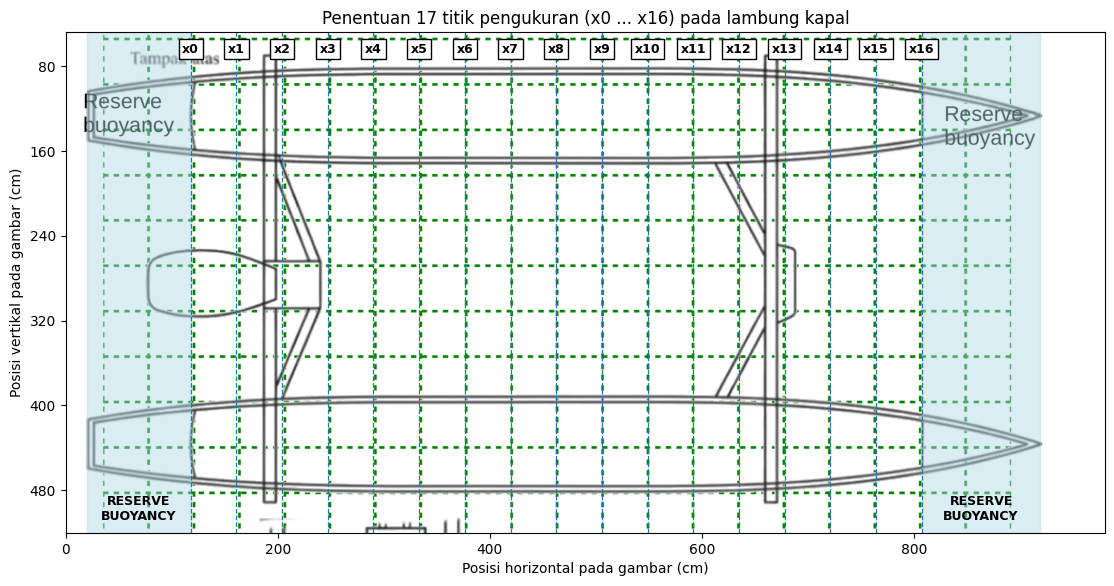

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6.5))
ax.imshow(pil)
ax.set_xlim(0, 2450); ax.set_ylim(1300, 120)

ax.axvspan(x_min, x_a, color="lightblue", alpha=0.45)
ax.axvspan(x_b, x_max, color="lightblue", alpha=0.45)
for i, xp in enumerate(xs_px):
    ax.axvline(xp, color="tab:blue", ls="--", lw=0.9)
    ax.text(xp, 160, f"x{i}", ha="center", va="center", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="square", fc="white", ec="black"))
ax.text((x_min + x_a) / 2, 1270, "RESERVE\nBUOYANCY", ha="center", fontsize=9, fontweight="bold")
ax.text((x_b + x_max) / 2, 1270, "RESERVE\nBUOYANCY", ha="center", fontsize=9, fontweight="bold")

ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*CM:.0f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*CM:.0f}"))
ax.set_xlabel("Posisi horizontal pada gambar (cm)")
ax.set_ylabel("Posisi vertikal pada gambar (cm)")
ax.set_title("Penentuan 17 titik pengukuran (x0 ... x16) pada lambung kapal")
plt.show()

### 10.2 Area lambung yang dihitung
Area merah adalah bagian kedua lambung yang dihitung volumenya (sudah dikurangi reserve buoyancy). Area abu-abu tidak dihitung.

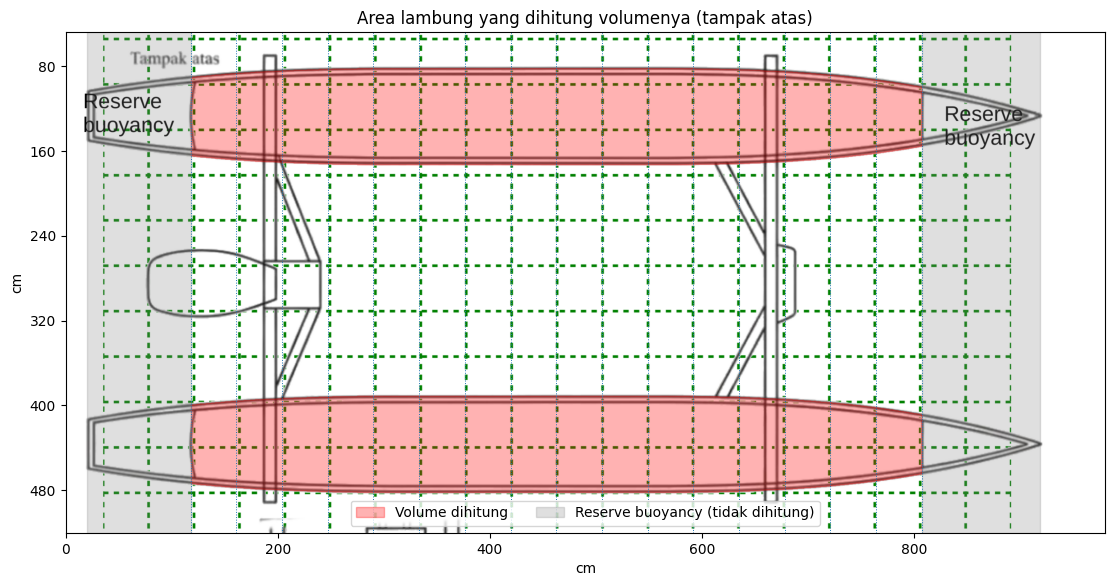

In [ ]:
m = (X >= x_a) & (X <= x_b)

fig, ax = plt.subplots(figsize=(15, 6.5))
ax.imshow(pil)
ax.set_xlim(0, 2450); ax.set_ylim(1300, 120)

for pc in (pusat_atas, pusat):                       # kedua lambung, bentuknya identik
    ax.fill_between(X[m], pc - setengah_ok[m], pc + setengah_ok[m],
                    color="red", alpha=0.30, label="Volume dihitung" if pc == pusat else None)
ax.axvspan(x_min, x_a, color="gray", alpha=0.25)
ax.axvspan(x_b, x_max, color="gray", alpha=0.25, label="Reserve buoyancy (tidak dihitung)")
for xp in xs_px:
    ax.axvline(xp, color="tab:blue", ls=":", lw=0.7)

ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*CM:.0f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*CM:.0f}"))
ax.set_xlabel("cm"); ax.set_ylabel("cm")
ax.set_title("Area lambung yang dihitung volumenya (tampak atas)")
ax.legend(loc="lower center", ncol=2)
plt.show()

### 10.3 Tinggi lambung di tampak samping
Area merah menunjukkan T(x), yaitu jarak dari garis dek (garis putus hijau) sampai dasar lambung.

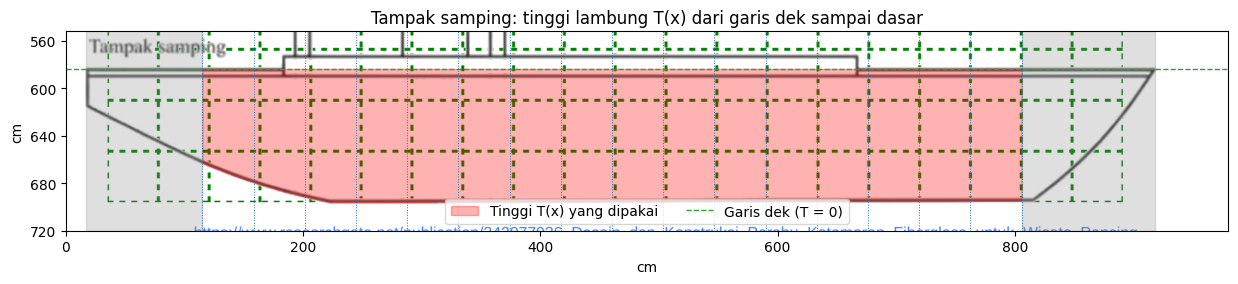

In [ ]:
s_a = s_min + (x_a - x_min) / (x_max - x_min) * (s_max - s_min)
s_b = s_min + (x_b - x_min) / (x_max - x_min) * (s_max - s_min)
ms = (S >= s_a) & (S <= s_b)

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.imshow(pil)
ax.set_xlim(0, 2450); ax.set_ylim(1800, 1380)
ax.fill_between(S[ms], dek, dasar[ms], color="red", alpha=0.30, label="Tinggi T(x) yang dipakai")
ax.axhline(dek, color="tab:green", lw=1, ls="--", label="Garis dek (T = 0)")
for xp in xs_px:
    sp = s_min + (xp - x_min) / (x_max - x_min) * (s_max - s_min)
    ax.axvline(sp, color="tab:blue", ls=":", lw=0.7)
ax.axvspan(s_min, s_a, color="gray", alpha=0.25)
ax.axvspan(s_b, s_max, color="gray", alpha=0.25)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*CM:.0f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*CM:.0f}"))
ax.set_xlabel("cm"); ax.set_ylabel("cm")
ax.set_title("Tampak samping: tinggi lambung T(x) dari garis dek sampai dasar")
ax.legend(loc="lower center", ncol=2)
plt.show()

### 10.4 Profil B(x), T(x), A(x)
Kurva biru adalah hasil pengukuran kontinu, titik merah adalah 17 titik yang dipakai.

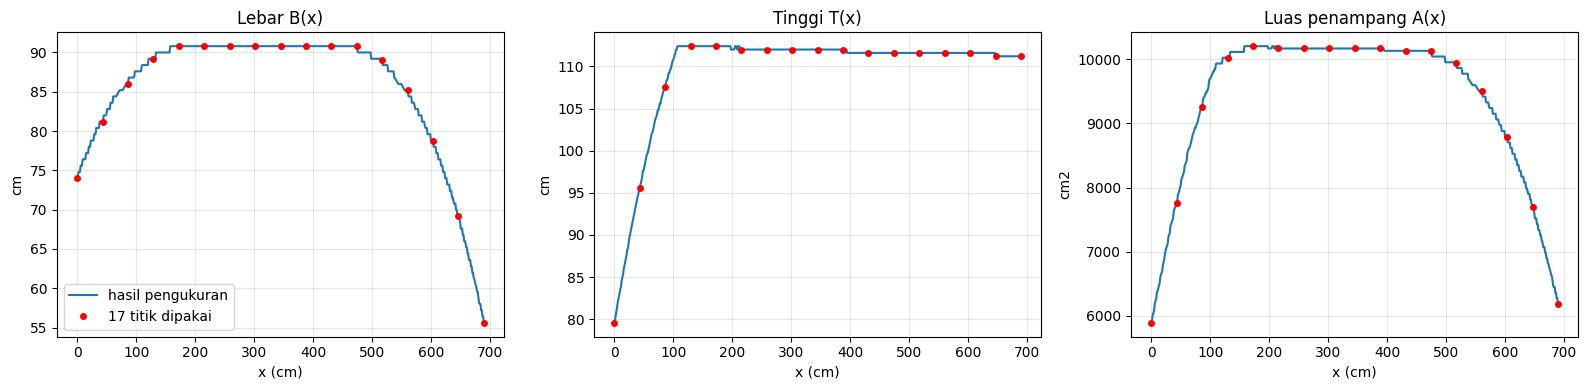

In [ ]:
xf = np.linspace(x_a, x_b, 600)
xcm = (xf - x_a) * CM
xt = tabel["x (cm)"]

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for ax, f, kol_, jud, sat in zip(
        axs,
        [B_cm(xf), T_cm(xf), A_cm2(xf)],
        ["B (cm)", "T (cm)", "A = B x T (cm2)"],
        ["Lebar B(x)", "Tinggi T(x)", "Luas penampang A(x)"],
        ["cm", "cm", "cm2"]):
    ax.plot(xcm, f, color="tab:blue", label="hasil pengukuran")
    ax.plot(xt, tabel[kol_], "ro", ms=4, label="17 titik dipakai")
    ax.set_title(jud); ax.set_xlabel("x (cm)"); ax.set_ylabel(sat); ax.grid(alpha=0.3)
axs[0].legend()
plt.tight_layout()
plt.show()

**Interpretasi grafik:**
- B(x) berbentuk mirip bukit: naik, datar di tengah, lalu turun tajam di ujung kanan.
- T(x) naik cepat di awal lalu hampir konstan, sesuai bentuk dasar lambung.
- A(x) = B × T mengikuti B di ujung kanan dan mengikuti T di ujung kiri. Volume = **luas di bawah kurva A(x)**, dan inilah yang dihitung metode numerik.
- Titik merah menempel pada kurva, artinya 17 titik cukup untuk menangkap bentuknya.

## 11. Perhitungan volume
Dihitung dengan trapesium dan Simpson 1/3 pada $n=16$.

In [ ]:
A = tabel["A = B x T (cm2)"].values

V_trap = trapesium(A, h) / 1e6
V_simp = simpson(A, h) / 1e6
selisih_pct = abs(V_simp - V_trap) / V_simp * 100

print(f"Trapesium (n=16): {V_trap:.4f} m3 per lambung")
print(f"Simpson 1/3 (n=16): {V_simp:.4f} m3 per lambung")
print(f"Selisih kedua metode: {selisih_pct:.2f} %")
print("-" * 50)
print(f"VOLUME SATU LAMBUNG  : {V_simp:.3f} m3  = {V_simp*1000:,.0f} liter")
print(f"VOLUME DUA LAMBUNG   : {2*V_simp:.3f} m3  = {2*V_simp*1000:,.0f} liter")

Trapesium (n=16): 6.4778 m3 per lambung
Simpson 1/3 (n=16): 6.4911 m3 per lambung
Selisih kedua metode: 0.21 %
--------------------------------------------------
VOLUME SATU LAMBUNG  : 6.491 m3  = 6,491 liter
VOLUME DUA LAMBUNG   : 12.982 m3  = 12,982 liter


**Interpretasi:**
- **Satu lambung ≈ 6,49 m³** dan **kedua lambung ≈ 12,98 m³** (sekitar 12.980 liter).
- Trapesium dan Simpson berselisih hanya sekitar **0,2%**, sehingga hasilnya konsisten. Simpson dipakai sebagai jawaban utama karena lebih akurat (galat $O(h^4)$).
- Pemeriksaan kewajaran: 13 m³ air laut sekitar 13 ton, itu daya apung maksimum teoretis kedua lambung. Angkanya masuk akal untuk perahu sekitar 9 m.

### 11.1 Hitung manual (Simpson n = 4)
Untuk membuktikan metodenya dipahami, dipakai hanya 5 titik (x0, x4, x8, x12, x16) dengan h ≈ 172,35 cm. Ini bisa dihitung dengan kalkulator dan ditulis tangan di laporan.

In [ ]:
idx = [0, 4, 8, 12, 16]
A4 = A[idx]
h4 = h * 4
suku = [A4[0], 4 * A4[1], 2 * A4[2], 4 * A4[3], A4[4]]

print(f"h = {h4:.2f} cm")
print("A0, A4, A8, A12, A16 (cm2):", A4.round(0))
print("suku bobot (1,4,2,4,1)   :", np.round(suku, 0))
V4 = h4 / 3 * sum(suku) / 1e6
print(f"V = h/3 x jumlah suku = {h4:.2f}/3 x {sum(suku):,.0f} = {V4:.4f} m3 per lambung")

h = 172.35 cm
A0, A4, A8, A12, A16 (cm2): [ 5888. 10206. 10170.  9944.  6183.]
suku bobot (1,4,2,4,1)   : [ 5888. 40824. 20339. 39774.  6183.]
V = h/3 x jumlah suku = 172.35/3 x 113,008 = 6.4923 m3 per lambung


**Interpretasi:** hasil manual **6,492 m³** sangat dekat dengan n = 16 (6,491 m³). Penyebabnya, bagian tengah lambung hampir seragam sehingga 5 titik pun sudah cukup menangkap bentuknya.

## 12. Uji konvergensi
Hitungan diulang dengan $n$ makin besar (memakai profil hasil pengukuran piksel). Hasilnya dibandingkan dengan nilai pembanding (Simpson, n = 4096) untuk melihat seberapa cepat tiap metode mendekati nilai sebenarnya.

,n,Simpson (m3),Trapesium (m3),galat Simpson (%),galat Trapesium (%)
0,2,6.0609,5.5859,6.5946,13.9148
1,4,6.4923,6.2657,0.0537,3.4384
2,8,6.4951,6.4377,0.0957,0.7878
3,16,6.4911,6.4778,0.0347,0.1709
4,32,6.4890,6.4862,0.0024,0.0410
5,64,6.4897,6.4888,0.0138,0.0001
6,128,6.4906,6.4901,0.0266,0.0200
7,256,6.4886,6.4890,0.0035,0.0023
8,512,6.4889,6.4889,0.0003,0.0008


Nilai pembanding (Simpson n=4096): 6.4888 m3


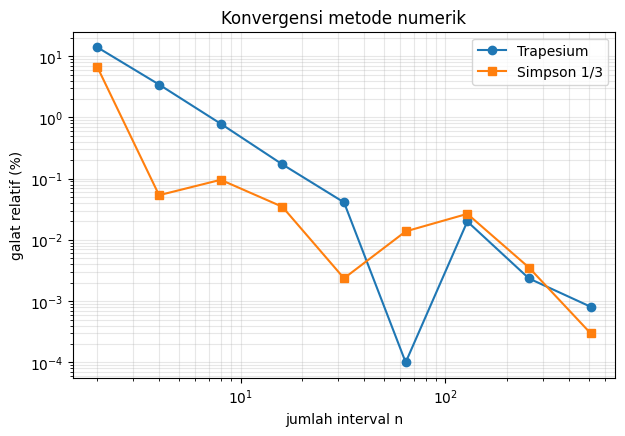

In [ ]:
ns = [2, 4, 8, 16, 32, 64, 128, 256, 512]
ref = volume(x_a, x_b, n=4096, metode="simpson")      # pembanding (n sangat besar)

baris = []
for k in ns:
    vs, vt = volume(x_a, x_b, k, "simpson"), volume(x_a, x_b, k, "trapesium")
    baris.append([k, vs, vt, abs(vs - ref) / ref * 100, abs(vt - ref) / ref * 100])
konv = pd.DataFrame(baris, columns=["n", "Simpson (m3)", "Trapesium (m3)",
                                    "galat Simpson (%)", "galat Trapesium (%)"])
display(konv.round(4))
print(f"Nilai pembanding (Simpson n=4096): {ref:.4f} m3")

plt.figure(figsize=(7, 4.5))
plt.loglog(konv["n"], konv["galat Trapesium (%)"].clip(lower=1e-4), "o-", label="Trapesium")
plt.loglog(konv["n"], konv["galat Simpson (%)"].clip(lower=1e-4), "s-", label="Simpson 1/3")
plt.xlabel("jumlah interval n"); plt.ylabel("galat relatif (%)")
plt.title("Konvergensi metode numerik"); plt.grid(alpha=0.3, which="both"); plt.legend()
plt.show()

**Interpretasi:**
- **Trapesium:** galat turun sekitar 4× setiap n digandakan (3,44% → 0,79% → 0,17% → 0,04%). Ini sesuai teori galat $O(h^2)$.
- **Simpson:** sudah sangat akurat sejak n = 4 (galat 0,05%), jauh lebih cepat dari trapesium.
- Setelah n besar, galat Simpson naik-turun di kisaran 0,00–0,03% dan tidak terus mengecil. Penyebabnya, profil hasil pengukuran sendiri punya ketidakpastian sekitar 1 piksel, sehingga ketelitian terbatas oleh **data**, bukan oleh metode.
- Kesimpulan: n = 16 sudah lebih dari cukup. Galat numeriknya jauh lebih kecil daripada galat pembacaan gambar.

## 13. Analisis sensitivitas: kenapa hasil tiap orang bisa berbeda?
Dua hal yang paling mudah membuat hasil berbeda diuji di sini: **skala** dan **posisi sekat**.

In [ ]:
V0 = volume(x_a, x_b, 16, "simpson")

# (a) pengaruh skala (volume sebanding dengan skala pangkat 3)
skala = {
    "Kalibrasi dash (hasil kode ini)": CM,
    "Salah baca: 1 kotak = 50 cm (5 dash)": 50 / jarak_grid_px,
    "Salah baca: 1 kotak = 40 cm (4 dash)": 40 / jarak_grid_px,
}
a = [[nama, s, V0 * (s / CM) ** 3, 2 * V0 * (s / CM) ** 3, (s / CM) ** 3 * 100 - 100]
     for nama, s in skala.items()]
tab_a = pd.DataFrame(a, columns=["Skenario skala", "cm per piksel", "V satu lambung (m3)",
                                 "V dua lambung (m3)", "beda vs kalibrasi (%)"])
print("(a) Pengaruh skala")
display(tab_a.round(3))

# (b) pengaruh posisi sekat (digeser 20 piksel = sekitar 8 cm)
d = 20
b = [["Sekat asli", x_a, x_b], ["Sekat kiri geser kiri", x_a - d, x_b], ["Sekat kiri geser kanan", x_a + d, x_b],
     ["Sekat kanan geser kiri", x_a, x_b - d], ["Sekat kanan geser kanan", x_a, x_b + d]]
b = [[nm, volume(p, q, 16, "simpson")] for nm, p, q in b]
tab_b = pd.DataFrame(b, columns=["Skenario batas", "V satu lambung (m3)"])
tab_b["beda vs asli (%)"] = (tab_b["V satu lambung (m3)"] / V0 - 1) * 100
print("(b) Pengaruh posisi sekat (geser 20 piksel = 8 cm)")
display(tab_b.round(3))

(a) Pengaruh skala


,Skenario skala,cm per piksel,V satu lambung (m3),V dua lambung (m3),beda vs kalibrasi (%)
0,Kalibrasi dash (hasil kode ini),0.400,6.491,12.982,0.000
1,Salah baca: 1 kotak = 50 cm (5 dash),0.467,10.349,20.698,59.433
2,Salah baca: 1 kotak = 40 cm (4 dash),0.374,5.299,10.597,-18.370


(b) Pengaruh posisi sekat (geser 20 piksel = 8 cm)


,Skenario batas,V satu lambung (m3),beda vs asli (%)
0,Sekat asli,6.491,0.000
1,Sekat kiri geser kiri,6.543,0.801
2,Sekat kiri geser kanan,6.438,-0.824
3,Sekat kanan geser kiri,6.435,-0.870
4,Sekat kanan geser kanan,6.533,0.644


**Interpretasi:**
- **Skala adalah faktor paling berbahaya.** Jika satu kotak dianggap 50 cm (5 dash), volumenya melonjak ke 10,35 m³ per lambung (**+59%**), padahal salah baca skala hanya sekitar 17%. Jika dianggap 40 cm, volumenya turun 18%. Itu karena volume sebanding dengan skala **pangkat 3**.
- **Posisi sekat** kurang berpengaruh: geser 20 piksel (8 cm) hanya mengubah volume sekitar **±0,8%**.
- Jadi perbedaan besar antar mahasiswa hampir pasti berasal dari **skala**, bukan dari metode numeriknya.

## 14. Hasil akhir

In [ ]:
V1 = volume(x_a, x_b, 16, "simpson")
print("=" * 55)
print("HASIL AKHIR (Simpson 1/3, n = 16)")
print("=" * 55)
print(f"Volume satu lambung : {V1:.3f} m3  ({V1*1000:,.0f} liter)")
print(f"Volume kedua lambung: {2*V1:.3f} m3  ({2*V1*1000:,.0f} liter)")
print("=" * 55)

HASIL AKHIR (Simpson 1/3, n = 16)
Volume satu lambung : 6.491 m3  (6,491 liter)
Volume kedua lambung: 12.982 m3  (12,982 liter)


## 15. Kesimpulan
1. Volume dihitung dengan $V=\int A(x)\,dx$, $A=B\cdot T$, memakai **Simpson 1/3 (n = 16)** dan dibandingkan dengan trapesium.
2. **Volume satu lambung ≈ 6,49 m³**, **volume kedua lambung ≈ 12,98 m³** (≈ 12.980 liter).
3. Simpson dan trapesium selisih ±0,2%, dan hasil konvergen saat n diperbesar, sehingga galat numerik kecil.

